# MSE path  (CNN compressor on raw cubes, MSE objective)
The 3D CNN compressor is trained to regress the parameters directly (MSE), then the shared NLE + MCMC machinery is applied.

## Setup

In [2]:
import os, glob, subprocess
from pathlib import Path
from IPython.display import Image, display
import pandas as pd, yaml

os.environ["MPLBACKEND"] = "Agg"  # headless plotting for the CLI tools
REPO = subprocess.check_output(["git", "rev-parse", "--show-toplevel"]).decode().strip()
os.chdir(REPO)
print("repo:", REPO)


def sh(cmd):
    """Run a shell command, echoing it first; its output streams into the cell."""
    print("$", cmd, flush=True)
    return subprocess.run(cmd, shell=True)


def show(path, width=1000):
    """Display a PNG, or rasterize + display page 1 of a PDF (needs pdftoppm)."""
    p = str(path)
    if p.endswith(".png") and os.path.exists(p):
        display(Image(p, width=width))
        return
    if p.endswith(".pdf") and os.path.exists(p):
        prev = p[:-4] + "_preview"
        if os.system(
            f'pdftoppm -png -r 150 -singlefile "{p}" "{prev}" 2>/dev/null'
        ) == 0 and os.path.exists(prev + ".png"):
            display(Image(prev + ".png", width=width))
            return
    print("figure not found:", p)

repo: /obs/ddehiwalage-don/21cm/sbi_project


## Config

In [3]:
# ---- path identity -------------------------------------------------------
PATHDIR = "mse"  # figures -> notebooks/figs_<PATHDIR>/
CONFIG = [
    "configs_seeds/mse_/arm_cnn_mse_n1.yaml",
]  # arm config(s) to run
# other mse arms: configs_seeds/mse_/arm_cnn_mse_1.yaml , arm_cnn_mse_2.yaml

# ---- sweep knobs ---------------------------------------------------------
SEEDS = [43]  # compressor.init_seed values, one run each
FAMILY = "nsf"  # NLE density family/families: gmm | maf | nsf
SCOPE = "std"  # t-scaling(s): std (standardized) | raw
STAGES = "1"  # 1=compressor, 2=NLE, 3=MCMC
NAMES = "Fx tau rHS Mmin"  # physical parameter names (plot legends)
NOTE = "mse path — CNN compressor, MSE objective"
PUSH = False  # git-commit + push experiments/manifest.csv after launch

# ---- figure sub-dirs for THIS path --------------------------------------
FIGS = Path("notebooks") / f"figs_{PATHDIR}"
DIR_COMP, DIR_NLE, DIR_SBC = FIGS / "compressor", FIGS / "nle", FIGS / "sbc"
for d in (DIR_COMP, DIR_NLE, DIR_SBC):
    d.mkdir(parents=True, exist_ok=True)


# ---- resolve each run's directory from its own YAML ---------------------
def nle_dir(config, s):
    c = yaml.safe_load(open(config))
    return f"{c['scratch_root']}/{c['arm_name']}_s{s}/nle"


def cfg_tag(config):
    return Path(config).stem.replace("arm_", "")


print("path    :", PATHDIR, "| figures ->", FIGS)
print("family  :", FAMILY, "| scope:", SCOPE, "| stages:", STAGES, "| seeds:", SEEDS)
for config in CONFIG:
    for s in SEEDS:
        d = nle_dir(config, s)
        print(f"  {cfg_tag(config)} s{s}: {d}  {'OK' if os.path.isdir(d) else 'missing'}")

path    : mse | figures -> notebooks/figs_mse
family  : nsf | scope: std | stages: 1 | seeds: [43]
  cnn_mse_n1 s43: /gscratch/ddehiwalage-don/sbi_master/cnn_mse_/n1/seed_s43/nle  OK


## 1 · Run experiment  (stages 1→2→3, SLURM)

In [13]:
# Launch stages 1->2->3 for each config on SLURM. This SUBMITS and returns at once;
# wait for the jobs to finish (squeue below) before running the plot cells.
# seeds = ' '.join(map(str, SEEDS))
# push  = '--push' if PUSH else ''
# for config in CONFIG:
#    sh(f'python experiments/run_sweep.py "{config}" --seeds {seeds} '
#       f'--family "{FAMILY}" --scope "{SCOPE}" --stages {STAGES} '
#         f'--note "{NOTE}" {push}')

In [14]:
# sh('squeue --me')

In [15]:
# bash submit_nle_grid.sh configs_seeds/mse_/arm_cnn_mse_n1.yaml -o compressor.init_seed=0 "gmm nsf" "std raw" 1

## 2 · Compressor training

$ python tools/plot_training_compressor.py cnn_mse_n1_s43=/gscratch/ddehiwalage-don/sbi_master/cnn_mse_/n1/seed_s43/nle --names Fx tau rHS Mmin --out "notebooks/figs_mse/compressor/mse_compressor.pdf" --png


[warn] 'cnn_mse_n1_s43': no sigma_history.npy


wrote notebooks/figs_mse/compressor/mse_compressor.pdf
wrote notebooks/figs_mse/compressor/mse_compressor.png

best RF-R2 (per parameter):
  arm                        Fx       tau       rHS      Mmin
  cnn_mse_n1_s43          0.999     0.997     0.964     0.999

final RF-R2 (per parameter):
  arm                        Fx       tau       rHS      Mmin
  cnn_mse_n1_s43          0.991     0.995     0.959     0.994

RF-R2 at best-probe checkpoint (the one exported):
  arm                        Fx       tau       rHS      Mmin
  cnn_mse_n1_s43          0.996     0.997     0.963     0.996

wrote notebooks/figs_mse/compressor/mse_compressor.tex  (RF-R2 at the exported checkpoint, \input{}-ready)


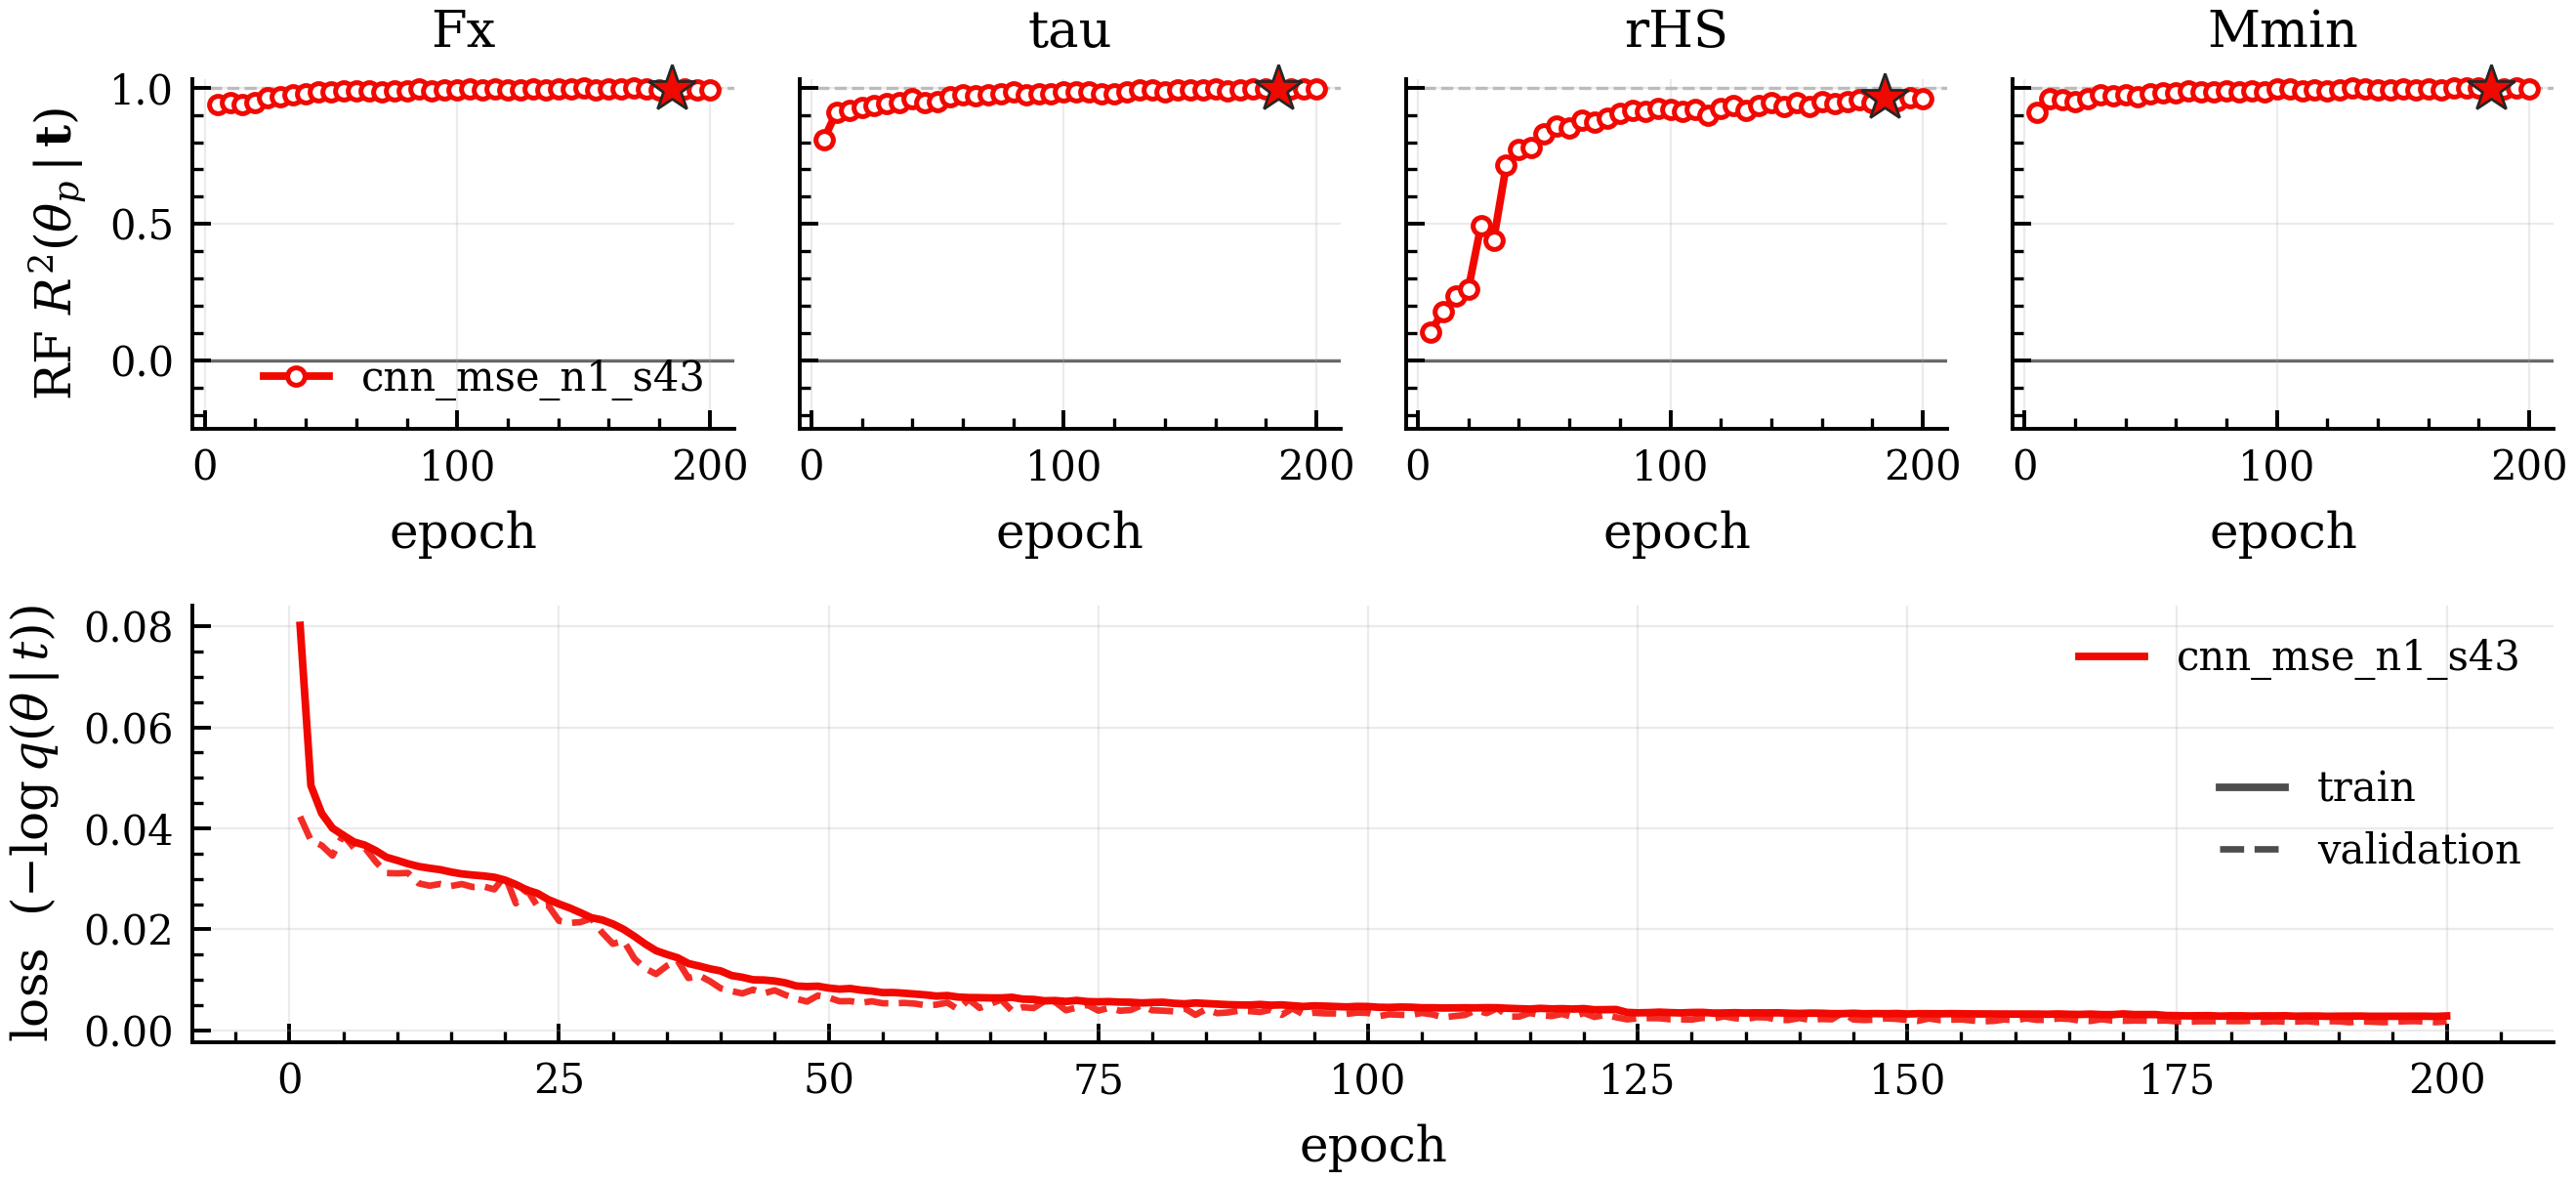

In [4]:
# Compressor training: RF-R^2 / conditional-sigma / loss, every (config, seed) overlaid.
arms = " ".join(f"{cfg_tag(c)}_s{s}={nle_dir(c, s)}" for c in CONFIG for s in SEEDS)
fig = DIR_COMP / f"{PATHDIR}_compressor.pdf"
sh(f'python tools/plot_training_compressor.py {arms} --names {NAMES} --out "{fig}" --png')
show(fig.with_suffix(".png"), width=1100)

## 3 · NLE training

$ python tools/plot_training_nle.py "configs_seeds/mse_/arm_cnn_mse_n1.yaml" --seeds 43 --models gmm nsf --out "notebooks/figs_mse/nle/mse_nlef.png"
[arm_cnn_mse_n1] discovered seeds=[43]  with loss data=[43]

[SUCCESS] wrote notebooks/figs_mse/nle/mse_nlef.png


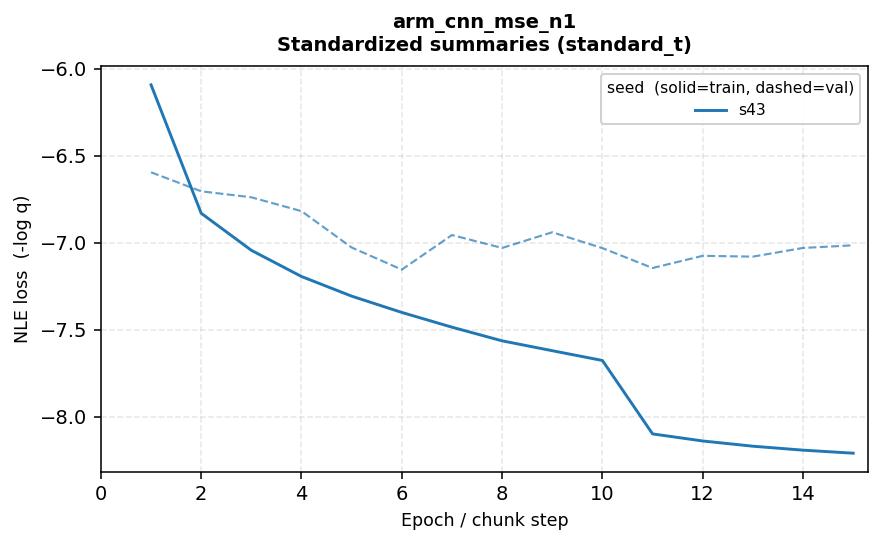

In [5]:
# NLE training: train (solid) / val (dashed) loss per family, all seeds overlaid ..// ..//
seeds = " ".join(map(str, SEEDS))
cfgs = " ".join(f'"{c}"' for c in CONFIG)
fig = DIR_NLE / f"{PATHDIR}_nlef.png"
sh(f'python tools/plot_training_nle.py {cfgs} --seeds {seeds} --models {FAMILY} --out "{fig}"')
show(fig, width=1000)

In [2]:
# bash submit_nle_grid.sh configs_seeds/mse_/arm_cnn_mse_n1.yaml -o compressor.init_seed=0 "gmm nsf" "std raw" 1
# bash submit_nle_grid.sh configs_seeds/mse_/arm_cnn_mse_n1.yaml -o compressor.init_seed=1 "gmm nsf" "std raw" 1
# bash submit_nle_grid.sh configs_seeds/mse_/arm_cnn_mse_n1.yaml -o compressor.init_seed=2 "gmm nsf" "std raw" 1
# bash submit_nle_grid.sh configs_seeds/mse_/arm_cnn_mse_n1.yaml -o compressor.init_seed=3 "gmm nsf" "std raw" 1


bash: submit_nle_grid.sh: No such file or directory


## 4 · SBC campaign

In [5]:
# SBC campaign (stage 4 / eval.py): rank histograms, coverage metrics, overlay corner.
# One --item per (config, family, scope); seeds averaged with --all-seeds.
items = [
    f"{c}|{fam}|{sc}|{cfg_tag(c)} {fam}/{sc}"
    for c in CONFIG
    for fam in FAMILY.split()
    for sc in SCOPE.split()
]
item_args = " ".join(f'--item "{it}"' for it in items)
seeds = " ".join(map(str, SEEDS))
sh(
    f'CUDA_VISIBLE_DEVICES="" python eval.py {item_args} --all-seeds --seeds {seeds} '
    f'--dlogp 10 --corner-sim 708 --out "{DIR_SBC}"'
)
# Heavy campaign? submit instead of running inline:
#   sbatch slurm/stage4_nb.sbatch raw {item_args} --all-seeds --seeds {seeds} --out {DIR_SBC}

$ CUDA_VISIBLE_DEVICES="" python eval.py --item "configs_seeds/mse_/arm_cnn_mse_n1.yaml|nsf|std|cnn_mse_n1 nsf/std" --all-seeds --seeds 43 --dlogp 10 --corner-sim median --out "notebooks/figs_mse/sbc"
[all-seeds] cnn_mse_/n1/seed [standard_t_nsf] -> seeds [43]
arms:
   cnn_mse_n1 nsf/std s43       <- seed_s43[standard_t_nsf]  (/gscratch/ddehiwalage-don/sbi_master/cnn_mse_/n1/seed_s43/chains/standard_t_nsf)
shared sims across arms: 908
[mode] filtered dlogp10
[table] wrote notebooks/figs_mse/sbc/metrics.csv  (filtered dlogp10)
[table] wrote notebooks/figs_mse/sbc/metrics.tex

=== GV (median sqrt|Sigma_4x4|) / sigma (median IQR) / chi^2-to-flat ===
  cnn_mse_n1 nsf/std s43     N= 908 GV=3.053e-08 sigma=[0.0104, 0.0119, 0.0379, 0.0102] chi2=[0.053, 0.038, 0.097, 0.061]
[table] wrote notebooks/figs_mse/sbc/metrics_seedavg.csv  (seed-averaged)
[table] wrote notebooks/figs_mse/sbc/metrics_seedavg.tex  (seed-averaged)

=== seed-averaged (geom-mean sigma/GV, arith-mean calib_ratio; ratio=1 -> 

CompletedProcess(args='CUDA_VISIBLE_DEVICES="" python eval.py --item "configs_seeds/mse_/arm_cnn_mse_n1.yaml|nsf|std|cnn_mse_n1 nsf/std" --all-seeds --seeds 43 --dlogp 10 --corner-sim median --out "notebooks/figs_mse/sbc"', returncode=0)

In [ ]:
m = DIR_SBC / "metrics.csv"
if m.exists():
    display(pd.read_csv(m))
for pdf in sorted(glob.glob(str(DIR_SBC / "*.pdf"))):
    print(os.path.basename(pdf))
    show(pdf, width=850)

In [3]:
!python check_nle.py /gscratch/ddehiwalage-don/sbi_master/cnn_mse_/n1 --expected-chunks 15


=== Root: n1 ===
  [WARN] root does not exist

All seeds successfully trained!
